# ACE (Atomic Cluster Expansion) Descriptors

This notebook demonstrates the Atomic Cluster Expansion (ACE) descriptors, which provide a systematic and complete framework for representing atomic environments in machine learning potentials.

## Background

ACE was introduced by Drautz (2019) as a unified framework that encompasses many existing descriptors:
- **SOAP** (Smooth Overlap of Atomic Positions) is ACE with ν=2
- **Bispectrum/SNAP** corresponds to ACE with ν=3

The key insight is constructing rotationally invariant descriptors by coupling products of single-particle basis functions (A-functions) using angular momentum algebra.

### The ACE Hierarchy

1. **A-functions** (single-particle basis):
   $$A_{i,nlm} = \sum_{j \in \text{neighbors}(i)} R_n(r_{ij}) Y_l^m(\hat{r}_{ij})$$

2. **B-basis** (rotationally invariant):
   - ν=1: $B_{i,n}^{(1)} = A_{i,n00}$ (radial density)
   - ν=2: $B_{i,n_1n_2l}^{(2)} = \sum_m A_{i,n_1lm}^* A_{i,n_2lm}$ (power spectrum)
   - ν=3: Triple products with Clebsch-Gordan coupling (bispectrum-like)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
import pyscal

## Basic Usage

Let's compute ACE descriptors for an FCC copper structure.

In [2]:
# Create FCC copper structure
atoms = bulk("Cu", "fcc", cubic=True).repeat(3)
print(f"Number of atoms: {len(atoms)}")

# Find neighbors
pyscal.find_neighbors(atoms, method="cutoff", cutoff=4.0)

# Compute ACE descriptors
result = pyscal.ace(atoms, nmax=4, lmax=3, nu_max=2)

print(f"\nACE descriptor shapes:")
print(f"  nu=1 (radial): {result['nu1'].shape}")
print(f"  nu=2 (power spectrum): {result['nu2'].shape}")
print(f"  full (concatenated): {result['full'].shape}")

Number of atoms: 108

ACE descriptor shapes:
  nu=1 (radial): (108, 4)
  nu=2 (power spectrum): (108, 40)
  full (concatenated): (108, 44)


## Understanding ACE Parameters

### Effect of `nmax` (radial resolution)

In [3]:
atoms = bulk("Cu", "fcc", cubic=True).repeat(2)
pyscal.find_neighbors(atoms, method="cutoff", cutoff=4.0)

print("Effect of nmax on descriptor count:")
print("-" * 40)
for nmax in [2, 4, 6, 8]:
    result = pyscal.ace(atoms, nmax=nmax, lmax=2, nu_max=2)
    print(f"nmax={nmax}: nu1={result['nu1'].shape[1]:3d}, nu2={result['nu2'].shape[1]:3d}, total={result['full'].shape[1]:3d}")

Effect of nmax on descriptor count:
----------------------------------------
nmax=2: nu1=  2, nu2=  9, total= 11
nmax=4: nu1=  4, nu2= 30, total= 34
nmax=6: nu1=  6, nu2= 63, total= 69
nmax=8: nu1=  8, nu2=108, total=116


### Effect of `lmax` (angular resolution)

In [4]:
print("Effect of lmax on descriptor count:")
print("-" * 40)
for lmax in [0, 2, 4, 6]:
    result = pyscal.ace(atoms, nmax=3, lmax=lmax, nu_max=2)
    print(f"lmax={lmax}: nu1={result['nu1'].shape[1]:3d}, nu2={result['nu2'].shape[1]:3d}, total={result['full'].shape[1]:3d}")

Effect of lmax on descriptor count:
----------------------------------------
lmax=0: nu1=  3, nu2=  6, total=  9
lmax=2: nu1=  3, nu2= 18, total= 21
lmax=4: nu1=  3, nu2= 30, total= 33
lmax=6: nu1=  3, nu2= 42, total= 45


### Effect of `nu_max` (correlation order)

In [5]:
print("Effect of nu_max on descriptor count:")
print("-" * 40)
for nu_max in [1, 2, 3]:
    result = pyscal.ace(atoms, nmax=3, lmax=2, nu_max=nu_max)
    components = [f"nu{i}" for i in range(1, nu_max+1)]
    sizes = [result[f'nu{i}'].shape[1] for i in range(1, nu_max+1)]
    print(f"nu_max={nu_max}: {dict(zip(components, sizes))}, total={result['full'].shape[1]}")

Effect of nu_max on descriptor count:
----------------------------------------
nu_max=1: {'nu1': 3}, total=3
nu_max=2: {'nu1': 3, 'nu2': 18}, total=21
nu_max=3: {'nu1': 3, 'nu2': 18, 'nu3': 10}, total=31


## Distinguishing Crystal Structures

ACE descriptors can distinguish between FCC, BCC, and HCP structures.

In [6]:
# Create different structures
structures = {
    'FCC (Cu)': bulk("Cu", "fcc", cubic=True).repeat(2),
    'BCC (Fe)': bulk("Fe", "bcc", cubic=True).repeat(2),
    'HCP (Mg)': bulk("Mg", "hcp").repeat((2, 2, 2))
}

# Compute descriptors
descriptors = {}
for name, atoms in structures.items():
    pyscal.find_neighbors(atoms, method="cutoff", cutoff=4.0)
    result = pyscal.ace(atoms, nmax=4, lmax=3, nu_max=2, normalize=False)
    descriptors[name] = result['full'].mean(axis=0)  # Average over atoms

# Compare using correlation
print("ACE descriptor correlation between structures:")
print("-" * 50)
names = list(descriptors.keys())
for i, name1 in enumerate(names):
    for name2 in names[i+1:]:
        d1, d2 = descriptors[name1], descriptors[name2]
        corr = np.corrcoef(d1, d2)[0, 1]
        print(f"{name1:10s} vs {name2:10s}: correlation = {corr:.4f}")

ACE descriptor correlation between structures:
--------------------------------------------------
FCC (Cu)   vs BCC (Fe)  : correlation = 0.9993
FCC (Cu)   vs HCP (Mg)  : correlation = 0.7171
BCC (Fe)   vs HCP (Mg)  : correlation = 0.7268


## Visualizing ACE Components

Let's examine the different correlation orders for FCC copper.

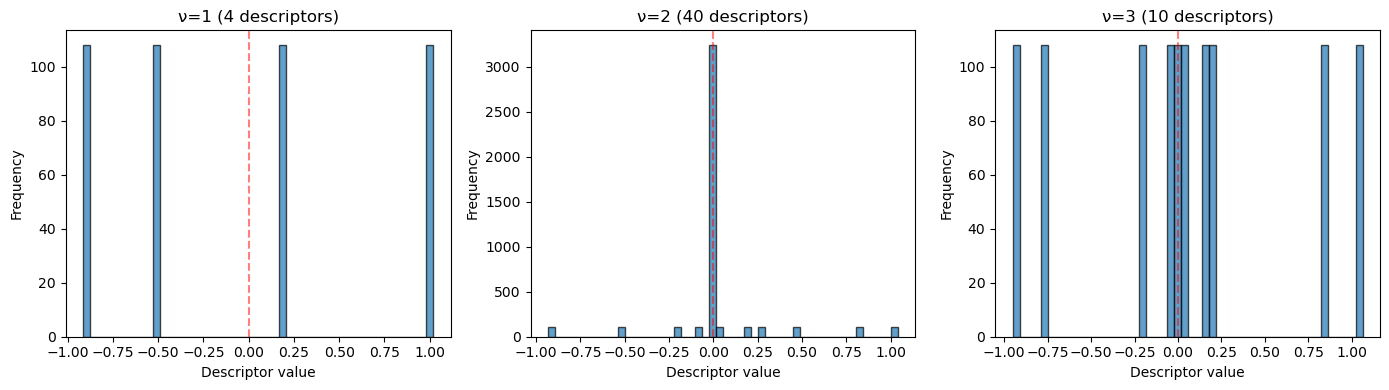


Descriptor statistics per correlation order:
ν=1: mean=-0.0500, std=0.7353, min=-0.9139, max=1.0201
ν=2: mean=0.0277, std=0.2852, min=-0.9323, max=1.0407
ν=3: mean=0.0401, std=0.5860, min=-0.9511, max=1.0617


In [7]:
atoms = bulk("Cu", "fcc", cubic=True).repeat(3)
pyscal.find_neighbors(atoms, method="cutoff", cutoff=4.0)
result = pyscal.ace(atoms, nmax=4, lmax=3, nu_max=3, normalize=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, nu in zip(axes, [1, 2, 3]):
    key = f'nu{nu}'
    data = result[key]
    
    # Plot histogram of descriptor values
    ax.hist(data.flatten(), bins=50, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Descriptor value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'ν={nu} ({data.shape[1]} descriptors)')
    ax.axvline(x=0, color='r', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nDescriptor statistics per correlation order:")
for nu in [1, 2, 3]:
    key = f'nu{nu}'
    data = result[key]
    print(f"ν={nu}: mean={data.mean():.4f}, std={data.std():.4f}, min={data.min():.4f}, max={data.max():.4f}")

## Comparison: ACE vs SOAP

ACE with ν=2 is equivalent to the SOAP power spectrum. Let's verify they capture similar information.

In [8]:
atoms = bulk("Cu", "fcc", cubic=True).repeat(2)
pyscal.find_neighbors(atoms, method="cutoff", cutoff=4.0)

# ACE with nu_max=2 (SOAP-like)
ace_result = pyscal.ace(atoms, nmax=4, lmax=3, nu_max=2, normalize=False)

print("ACE (nu_max=2) descriptor statistics:")
print(f"  nu=1 (radial):       {ace_result['nu1'].shape[1]} descriptors")
print(f"  nu=2 (power spectrum): {ace_result['nu2'].shape[1]} descriptors")
print(f"  Total:               {ace_result['full'].shape[1]} descriptors")

# The power spectrum part (nu=2) captures similar information to SOAP
print(f"\nnu=2 statistics:")
print(f"  Mean: {ace_result['nu2'].mean():.6f}")
print(f"  Std:  {ace_result['nu2'].std():.6f}")

ACE (nu_max=2) descriptor statistics:
  nu=1 (radial):       4 descriptors
  nu=2 (power spectrum): 40 descriptors
  Total:               44 descriptors

nu=2 statistics:
  Mean: 0.027656
  Std:  0.285186


## Descriptor Fingerprints

Let's create a fingerprint visualization for different structures.

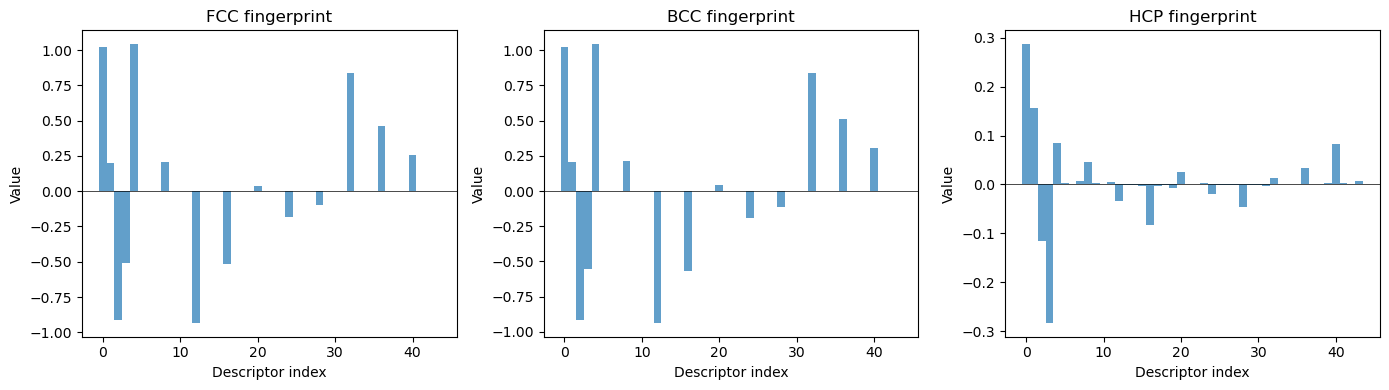

In [9]:
# Create structures
structures = {
    'FCC': bulk("Cu", "fcc", cubic=True).repeat(2),
    'BCC': bulk("Fe", "bcc", cubic=True).repeat(2),
    'HCP': bulk("Mg", "hcp").repeat((2, 2, 2))
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, atoms) in zip(axes, structures.items()):
    pyscal.find_neighbors(atoms, method="cutoff", cutoff=4.0)
    result = pyscal.ace(atoms, nmax=4, lmax=3, nu_max=2, normalize=False)
    
    # Average descriptor
    mean_desc = result['full'].mean(axis=0)
    
    ax.bar(range(len(mean_desc)), mean_desc, width=1.0, alpha=0.7)
    ax.set_xlabel('Descriptor index')
    ax.set_ylabel('Value')
    ax.set_title(f'{name} fingerprint')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

## Stored Results

ACE results are automatically stored in the atoms object.

In [ ]:
atoms = bulk("Cu", "fcc", cubic=True).repeat(2)
pyscal.find_neighbors(atoms, method="cutoff", cutoff=4.0)
pyscal.ace(atoms, nmax=4, lmax=3, nu_max=2)

print("Stored in atoms.arrays:")
print(f"  pyscal_ace shape: {atoms.arrays['pyscal_ace'].shape}")

print("\nStored in atoms.info:")
print(f"  pyscal_ace_params: {atoms.info['pyscal_ace_params']}")

## References

1. Drautz, R. (2019). "Atomic cluster expansion for accurate and transferable interatomic potentials." *Phys. Rev. B* 99, 014104.

2. Dusson et al. (2022). "Atomic cluster expansion: Completeness, efficiency and stability." *J. Comput. Phys.*

3. Bartók et al. (2010). "Gaussian approximation potentials: The accuracy of quantum mechanics..." *Phys. Rev. Lett.* 104, 136403.